# Pembuatan Gambar untuk Bab 3

Tiga gambar dihasilkan langsung dari CSV hasil *benchmark*, sehingga seluruh angka pada gambar konsisten dengan angka pada tabel.

| Gambar | Isi | Menggantikan |
| --- | --- | --- |
| Gambar 3 | *Throughput* efektif fase *write* terhadap ukuran *file* | Tabel 5 |
| Gambar 4 | Median latensi ketiga strategi pada tiga fase operasi | (baru) |
| Gambar 5 | Indeks latensi antar konfigurasi *hardware* | Tabel 9 |

Ubah `OUT` bila direktori keluaran berbeda. Berkas disimpan dalam format PDF (vektor) dan PNG 300 dpi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

DATA = Path('.')          # direktori berisi summary.csv dan benchmark_*.csv
OUT = Path('gambar')      # direktori keluaran
OUT.mkdir(exist_ok=True)

HW = ['1cpu_1g', '2cpu_2g', '4cpu_4g', '6cpu_4.5g']
HW_LABEL = ['1 CPU\n1 GB', '2 CPU\n2 GB', '4 CPU\n4 GB', '6 CPU\n4,5 GB']
APPROACH = ['mongo_gridfs', 'pg_bytea', 'polyglot']

# Pembeda antar strategi tidak boleh bergantung pada warna saja,
# karena artikel berpotensi dicetak hitam putih.
STYLE = {
    'mongo_gridfs': dict(color='#4C72B0', marker='o', linestyle='-'),
    'pg_bytea':     dict(color='#C44E52', marker='s', linestyle='--'),
    'polyglot':     dict(color='#55A868', marker='^', linestyle='-.'),
}
HATCH = {'mongo_gridfs': '', 'pg_bytea': '///', 'polyglot': '...'}

# Times New Roman agar selaras dengan template JAISE.
# Bila font tidak tersedia, matplotlib jatuh ke serif bawaan.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.4,
    'lines.markersize': 5,
    'figure.dpi': 110,
})

CM = 1 / 2.54  # lebar kolom penuh pada A4 dengan margin template kurang lebih 16 cm

koma = FuncFormatter(lambda v, _: f'{v:g}'.replace('.', ','))


def simpan(fig, nama):
    fig.savefig(OUT / f'{nama}.pdf', bbox_inches='tight')
    fig.savefig(OUT / f'{nama}.png', dpi=300, bbox_inches='tight')
    print('tersimpan:', nama)

In [3]:
summary = pd.read_csv(DATA / 'results/summary.csv')

# Ukuran rata-rata file per kategori diambil dari salah satu benchmark;
# dataset identik pada keempat konfigurasi sehingga nilainya sama.
bench = pd.read_csv(DATA / 'results/benchmark_1cpu_1g.csv')
ukuran = bench[bench.phase == 'write'].groupby('bucket').filesize_bytes.mean()
BUCKET = list(ukuran.sort_values().index)


def median(phase, approach, hw, bucket=None):
    m = ((summary.phase == phase) & (summary.approach == approach)
         & (summary.hardware_config == hw))
    if bucket is not None:
        m &= summary.bucket == bucket
    return summary.loc[m, 'median'].iloc[0]


def rata_geometrik(x):
    """Rata-rata geometrik, dipakai untuk menggabungkan empat kategori dataset
    pada fase write menjadi satu nilai wakil."""
    return float(np.exp(np.mean(np.log(np.asarray(x, dtype=float)))))


print(BUCKET)
print((ukuran.sort_values() / 1e6).round(3).to_dict())

['audio_small', 'audio_medium', 'video_small', 'video_medium']
{'audio_small': 0.381, 'audio_medium': 0.539, 'video_small': 5.475, 'video_medium': 13.092}


## Gambar 3. *Throughput* efektif fase *write*

Sumbu x adalah kategori dataset yang diurutkan menurut ukuran rata-rata *file* (0,38 MB hingga 13,09 MB). Kategori diberi jarak yang sama agar label terbaca. Pita di sekitar tiap garis menunjukkan rentang nilai pada keempat konfigurasi *hardware*.

tersimpan: gambar3_throughput_write


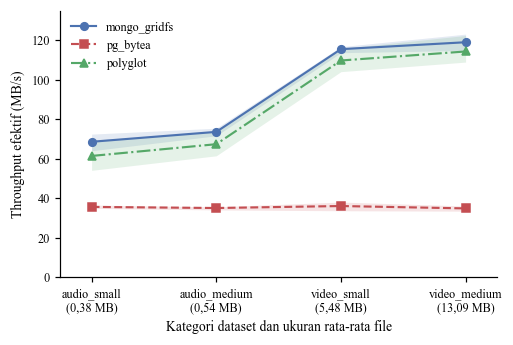

In [4]:
fig, ax = plt.subplots(figsize=(13 * CM, 8 * CM))

# Posisi kategori dibuat berjarak sama agar label tidak bertumpuk;
# ukuran file yang sebenarnya dicantumkan pada label sumbu x.
x = np.arange(len(BUCKET))
mb = [ukuran[b] / 1e6 for b in BUCKET]

for ap in APPROACH:
    rerata, bawah, atas = [], [], []
    for b in BUCKET:
        nilai = [ukuran[b] / median('write', ap, hw, b) / 1e6 for hw in HW]
        rerata.append(np.mean(nilai))
        bawah.append(min(nilai))
        atas.append(max(nilai))
    ax.plot(x, rerata, label=ap, **STYLE[ap])
    ax.fill_between(x, bawah, atas, color=STYLE[ap]['color'], alpha=0.15, linewidth=0)

ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n({v:.2f} MB)".replace('.', ',') for b, v in zip(BUCKET, mb)])
ax.set_xlim(-0.25, len(BUCKET) - 0.75)
ax.set_xlabel('Kategori dataset dan ukuran rata-rata file')
ax.set_ylabel('Throughput efektif (MB/s)')
ax.set_ylim(0, 135)
ax.yaxis.set_major_formatter(koma)
ax.legend(frameon=False, loc='upper left')

simpan(fig, 'gambar3_throughput_write')
plt.show()

## Gambar 4. Median latensi ketiga strategi pada tiga fase operasi

Konfigurasi 6 CPU / 4,5 GB. Nilai fase *write* merupakan rata-rata geometrik median keempat kategori dataset. Sumbu y logaritmik karena rentang latensi mencakup tiga orde besaran.

tersimpan: gambar4_latensi_per_fase


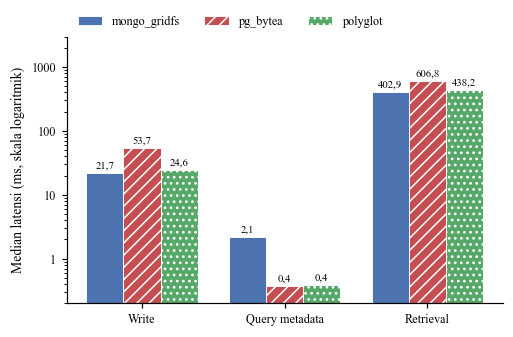

In [5]:
HW_PILIH = '6cpu_4.5g'
FASE = [('write', 'Write'), ('query', 'Query metadata'), ('read', 'Retrieval')]

nilai = {}
for ap in APPROACH:
    baris = []
    for fase, _ in FASE:
        if fase == 'write':
            v = rata_geometrik([median('write', ap, HW_PILIH, b) for b in BUCKET])
        else:
            v = median(fase, ap, HW_PILIH)
        baris.append(v * 1000)  # detik ke milidetik
    nilai[ap] = baris

fig, ax = plt.subplots(figsize=(13 * CM, 8 * CM))

posisi = np.arange(len(FASE))
lebar = 0.26

for i, ap in enumerate(APPROACH):
    offset = (i - 1) * lebar
    bar = ax.bar(posisi + offset, nilai[ap], lebar, label=ap,
                 color=STYLE[ap]['color'], edgecolor='white',
                 hatch=HATCH[ap], linewidth=0.6)
    ax.bar_label(bar, fmt=lambda v: f'{v:,.1f}'.replace('.', ','),
                 padding=2, fontsize=7)

ax.set_yscale('log')
ax.set_xticks(posisi)
ax.set_xticklabels([n for _, n in FASE])
ax.set_ylabel('Median latensi (ms, skala logaritmik)')
ax.set_ylim(0.2, 3000)
ax.yaxis.set_major_formatter(koma)
ax.legend(frameon=False, ncol=3, loc='upper left', bbox_to_anchor=(0, 1.12))

simpan(fig, 'gambar4_latensi_per_fase')
plt.show()

## Gambar 5. Indeks latensi antar konfigurasi *hardware*

Konfigurasi 1 CPU dijadikan basis 100. Nilai di bawah 100 berarti latensi menurun, nilai di atas 100 berarti latensi meningkat. Garis putus-putus horizontal menandai basis.

tersimpan: gambar5_indeks_skalabilitas


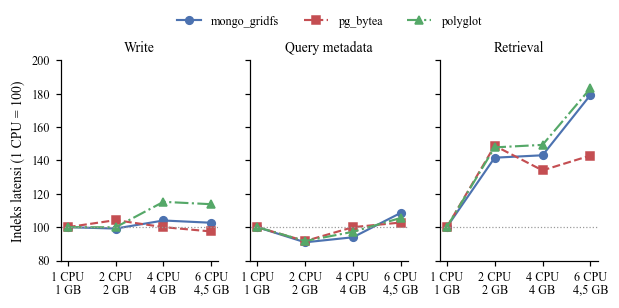

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16 * CM, 6 * CM), sharey=True)

for ax, (fase, judul) in zip(axes, FASE):
    for ap in APPROACH:
        deret = []
        for hw in HW:
            if fase == 'write':
                v = rata_geometrik([median('write', ap, hw, b) for b in BUCKET])
            else:
                v = median(fase, ap, hw)
            deret.append(v)
        indeks = np.array(deret) / deret[0] * 100
        ax.plot(range(len(HW)), indeks, label=ap, **STYLE[ap])

    ax.axhline(100, color='0.6', linewidth=0.8, linestyle=':')
    ax.set_xticks(range(len(HW)))
    ax.set_xticklabels(HW_LABEL)
    ax.set_title(judul)

axes[0].set_ylabel('Indeks latensi (1 CPU = 100)')
axes[0].set_ylim(80, 200)
axes[0].yaxis.set_major_formatter(koma)
axes[1].legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.28))

simpan(fig, 'gambar5_indeks_skalabilitas')
plt.show()

## Verifikasi angka

Sel berikut mencetak angka yang digambar agar dapat dicocokkan dengan tabel pada naskah.

In [7]:
print('Gambar 3, throughput (MB/s), rentang antar konfigurasi:')
for ap in APPROACH:
    for b in BUCKET:
        v = [ukuran[b] / median('write', ap, hw, b) / 1e6 for hw in HW]
        print(f'  {ap:<13} {b:<13} {min(v):6.1f} - {max(v):6.1f}')

print('\nGambar 4, median latensi (ms) pada 6 CPU:')
for ap in APPROACH:
    print(f'  {ap:<13} ' + '  '.join(f'{n:9.2f}' for n in nilai[ap]))

print('\nGambar 5, indeks latensi:')
for fase, judul in FASE:
    for ap in APPROACH:
        deret = [rata_geometrik([median('write', ap, hw, b) for b in BUCKET])
                 if fase == 'write' else median(fase, ap, hw) for hw in HW]
        idx = np.array(deret) / deret[0] * 100
        print(f'  {judul:<15} {ap:<13} ' + '  '.join(f'{v:6.1f}' for v in idx))

Gambar 3, throughput (MB/s), rentang antar konfigurasi:
  mongo_gridfs  audio_small     64.1 -   72.5
  mongo_gridfs  audio_medium    71.7 -   75.5
  mongo_gridfs  video_small    113.7 -  116.7
  mongo_gridfs  video_medium   114.9 -  123.1
  pg_bytea      audio_small     35.0 -   36.6
  pg_bytea      audio_medium    34.1 -   35.7
  pg_bytea      video_small     33.7 -   38.1
  pg_bytea      video_medium    33.5 -   36.1
  polyglot      audio_small     54.2 -   68.7
  polyglot      audio_medium    61.5 -   73.7
  polyglot      video_small    104.1 -  115.8
  polyglot      video_medium   109.0 -  122.4

Gambar 4, median latensi (ms) pada 6 CPU:
  mongo_gridfs      21.73       2.15     402.93
  pg_bytea          53.66       0.37     606.84
  polyglot          24.61       0.38     438.16

Gambar 5, indeks latensi:
  Write           mongo_gridfs   100.0    99.2   104.0   102.6
  Write           pg_bytea       100.0   104.2   100.0    97.4
  Write           polyglot       100.0    99.9   115